# Libraries

In [24]:
from typing import Optional, Literal, Generator
from warnings import warn
from tqdm.auto import tqdm
import gymnasium as gym

import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.optim import Adam
import numpy as np

import matplotlib.pyplot as plt

## ReplayBuffer: memory allocation and management

In [2]:
class MemoryBlock: 
    def __init__(self, 
                 state: torch.FloatTensor | np.ndarray, 
                 action: torch.IntTensor | np.ndarray, 
                 reward: torch.FloatTensor | np.ndarray, 
                 done: torch.IntTensor | np.ndarray,
                 next_state: Optional[torch.FloatTensor | np.ndarray] = None,
                 device: str = None
                 ):
        self.state = self._cast(state)  
        self.next_state = self._cast(next_state) if isinstance(next_state, (torch.Tensor, np.ndarray)) else None
        self.action = self._cast(action)
        self.reward = self._cast(reward)
        self.done = self._cast(done)
        
        if device:
            self.to(device)
    
    @staticmethod
    def _cast(x: list | torch.Tensor | np.ndarray) -> torch.Tensor:
        if isinstance(x, (list, float, int, np.number)):
            return torch.tensor(x)
        elif isinstance(x, np.ndarray):
            return torch.from_numpy(x)
        return x
    
    def to(self, device) -> None:
        self.state = self.state.to(device)
        if isinstance(self.next_state, (torch.Tensor, np.ndarray)):
            self.next_state = self.next_state.to(device)
        self.action = self.action.to(device)
        self.reward = self.reward.to(device)
        self.done = self.done.to(device)
        


class Memory:
    def __init__(self,
                 buffer_size: int, 
                 state_dim: int,
                 action_dim: int,
                 device: Literal["cpu", "cuda"],
                 with_next_state: Optional[bool] = False
                 ):
        self.with_next_state = with_next_state
        self.device = device
        self.buffer_size = buffer_size
        self.counter = 0
        
        self._states = torch.empty((self.buffer_size, state_dim), dtype=torch.float32, device=self.device)
        if self.with_next_state:
            self._next_states = torch.empty_like(self._states)
        self._actions = torch.empty((self.buffer_size, action_dim), dtype=torch.float32, device=self.device)
        self._rewards = torch.empty((self.buffer_size, 1), dtype=torch.float32, device=self.device)
        self._dones = torch.empty((self.buffer_size, 1), dtype=torch.int64, device=self.device)
        
    def __len__(self) -> int:
        return self.counter
    
    def clear(self) -> None:
        self._states.new_empty(size=self._states.size(), dtype=self._states.dtype, device=self._states.device)
        if self.with_next_state:
            self._next_states = torch.empty_like(self._states)
            
        self._actions.new_empty(size=self._actions.size(), dtype=self._actions.dtype, device=self._actions.device)
        self._rewards.new_empty(size=self._rewards.size(), dtype=self._rewards.dtype, device=self._rewards.device)
        self._dones.new_empty(size=self._dones.size(), dtype=self._dones.dtype, device=self._dones.device)
        self.counter = 0
    
    def __getitem__(self, index: slice) -> MemoryBlock:
        if self.with_next_state:
            return MemoryBlock(
                state=self._states[index], 
                next_state=self._next_states[index],
                action=self._actions[index], 
                reward=self._rewards[index], 
                done=self._dones[index]
            )
        return MemoryBlock(
            state=self._states[index],
            action=self._actions[index], 
            reward=self._rewards[index], 
            done=self._dones[index]
        )
    
    def __setitem__(self, index: slice, block: MemoryBlock) -> None:
        block.to(self.device)
        self._states[index] = block.state
        if self.with_next_state:
            self._next_states[index] = block.next_state
            
        self._actions[index] = block.action
        self._rewards[index] = block.reward
        self._dones[index] = block.done
        self.counter += 1
    
    def write(self, block: MemoryBlock) -> None:
        index = self.counter % self.buffer_size
        self[index] = block


class ReplayBuffer(Memory):
    def __init__(self, 
                 buffer_size: int, 
                 batch_size: int, 
                 state_dim: int, 
                 action_dim: int,
                 device: Literal["cpu", "cuda"], 
                 with_next_state: Optional[bool] = False
                 ):
        super().__init__(buffer_size, state_dim, action_dim, device, with_next_state)
        self.batch_size = batch_size
    
    def sample(self, from_indices: Optional[bool] = False) -> MemoryBlock:
        if len(self) >= self.batch_size:
            indices = torch.randint(
                0, min(len(self), self.buffer_size), 
                (self.batch_size,),
                dtype=torch.int64
            )
            return indices if from_indices else self[indices]
        warn(
            f"Can't sample MemoryBlock from ReplayBuffer "
            f"before len {len(self)} less then batch_size {self.batch_size}"
        )
    
    def get_dataloader(self, from_indices: Optional[bool] = False) -> Generator:
        train_steps = len(self) // self.batch_size
        for _ in range(train_steps):
            yield self.sample(from_indices)
            
    def catch_memory(self) -> MemoryBlock:
        return self[0: len(self)]
    
    def compute_returns(self, gamma: Optional[float] = 0.9) -> torch.Tensor:
        memory = self.catch_memory()
        rewards, dones = memory.reward, memory.done 
        returns = torch.zeros(len(rewards) + 1, device=self.device)
        for t in range(len(rewards) - 1, -1, -1):
            returns[t] = rewards[t] + gamma * returns[t + 1] * (1 - dones[t])
        return returns[:-1].unsqueeze(-1)

## PPO

In [11]:
class PPO(nn.Module):
    def __init__(self, 
                 env: gym.Env,
                 state_dim: Optional[int] = None,
                 action_dim: Optional[int] = None,
                 actor_lr: Optional[float] = 5e-4, 
                 critic_lr: Optional[float] = 5e-4,
                 epsilon: Optional[float] = 0.2,
                 gamma: Optional[float] = 0.9,
                 epoch_per_episode: Optional[int] = 30,
                 trajectories_per_episode: Optional[int] = 20, 
                 max_trajectory_steps: Optional[int] = None,
                 batch_size: Optional[int] = 128,
                 device: Optional[Literal["cpu", "cuda"]] = None,
                 advantage: Literal["returns", "temporal_difference"] = "returns"
                 ):
        super().__init__()
        if device is None:
            warn("No device was defined, device will be selected automatically")
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.env  = env
        self.state_dim = state_dim if state_dim else self.env.observation_space.shape[0]
        self.action_dim = action_dim if action_dim else self.env.action_space.shape[0]

        self.actor = nn.Sequential(
            nn.Linear(self.state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_dim * 2),
            nn.Tanh()
        ).to(device)
        
        self.critic = nn.Sequential(
            nn.Linear(self.state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(device)
        
        self.advantage = advantage
        self.epoch_per_episode = epoch_per_episode
        self.batch_size = batch_size
        self.device = device
        self.epsilon = epsilon
        self.gamma = gamma
        self.actor_lr = actor_lr
        self.critic_lr = critic_lr
        self._actor_optim = Adam(self.actor.parameters(), lr=self.actor_lr)
        self._critic_optim = Adam(self.critic.parameters(), lr=self.critic_lr) 
        
        self.trajectories_per_episode = trajectories_per_episode
        self.max_trajectory_steps = max_trajectory_steps if max_trajectory_steps else self.env._max_episode_steps
        self.buffer = ReplayBuffer(
            self.max_trajectory_steps * self.trajectories_per_episode, 
            self.batch_size, self.state_dim, 
            self.action_dim, self.device, 
            with_next_state=False if self.advantage == "returns" else True
        )
    
    def _actor_optim_step(self, loss: torch.Tensor) -> float:
        loss.backward()
        self._actor_optim.step()
        self._actor_optim.zero_grad()
        return loss.detach().cpu().item()

    def _critic_optim_step(self, loss: torch.Tensor) -> float:
        loss.backward()
        self._critic_optim.step()
        self._critic_optim.zero_grad()
        return loss.detach().cpu().item()
    
    def _cast_state(self, state: list | np.ndarray | torch.FloatTensor) -> torch.FloatTensor:
        if isinstance(state, (list, np.ndarray)):
            state = torch.FloatTensor(state)
        return state.to(self.device).unsqueeze(0)
    
    def _actor_forward(self, state: np.ndarray | torch.FloatTensor) -> tuple[torch.FloatTensor, torch.FloatTensor]:    
        state = self._cast_state(state)
        mean, sigma = self.actor.forward(state).T
        return mean, torch.exp(sigma)
    
    def _critic_forward(self, state: np.ndarray | torch.FloatTensor) -> torch.FloatTensor:
        state = self._cast_state(state)
        return self.critic.forward(state)
        
    def get_action(self, state: torch.Tensor | np.ndarray, from_numpy: Optional[bool] = True) -> torch.Tensor | np.ndarray:
        with torch.no_grad():
            mean, sigma = self._actor_forward(state)
            dist = Normal(mean, sigma)        
            action = dist.sample()             
        return action.cpu().numpy() if from_numpy else action

    def _get_action_log_probs(self, state: torch.FloatTensor, action: torch.FloatTensor) -> torch.Tensor:
       mean, sigma = self._actor_forward(state)
       dist = Normal(mean, sigma)
       return dist.log_prob(action)
        
    def _record_trajectory_on_buffer(self) -> float | int:
        total_reward = 0
        state, _ = self.env.reset()
        for _ in range(self.max_trajectory_steps):
            action = self.get_action(state, from_numpy=True)
            next_state, reward, truncated, done, info = env.step(action * 2)
            total_reward += reward
            
            step = MemoryBlock(
                state=state, 
                next_state=None if self.advantage == "retunrs" else next_state,
                action=action, 
                reward=reward, 
                done=truncated or done, 
                device=self.device
            )
            self.buffer.write(step)
            state = next_state

            if done is True:
                break
        return total_reward
    
    def _record_trajectories_on_buffer(self) -> list[int | float]:
        return [
            self._record_trajectory_on_buffer() 
            for _ in range(self.trajectories_per_episode)
        ]

    def step(self) -> None:
        returns = self.buffer.compute_returns(self.gamma).detach()
        memory = self.buffer.catch_memory()
        old_log_probs = self._get_action_log_probs(memory.state, memory.action).detach()
        
        for _ in range(self.epoch_per_episode):
            for indices in self.buffer.get_dataloader(True):
                # Get train batch as indices returns, states & actions 
                batched_states = memory.state[indices]
                batched_actions = memory.action[indices]
                batched_old_log_probs = old_log_probs[indices]
                
                # Compute Advantage & Critic Loss & Backward & Optimizer step
                if self.advantage == "returns":
                    batched_returns = returns[indices]
                    advantage = batched_returns - self._critic_forward(batched_states)
                else:
                    batched_reward = memory.reward[indices]
                    batched_next_states = memory.next_state[indices]
                    advantage = batched_reward + self.gamma * self._critic_forward(batched_next_states) - self._critic_forward(batched_states)
                    
                critic_loss = advantage.square().mean()
                self._critic_optim_step(critic_loss)
                
                # Compute Actor Loss & Backward & Optimizer step
                new_log_probs = self._get_action_log_probs(batched_states, batched_actions) # Compute action log probs
                ratio = torch.exp(new_log_probs - batched_old_log_probs) # Compute ratio as difference
                clamped_ratio = torch.clamp(ratio, 1. - self.epsilon, 1. + self.epsilon) # And just force clamped for stability
                conservative_loss = torch.min(ratio * advantage.detach(), clamped_ratio * advantage.detach()) # Choose more conservative loss
                actor_loss = -torch.mean(conservative_loss)
                self._actor_optim_step(actor_loss)
                
    def fit(self, 
            num_episodes: Optional[int] = 100, 
            trajectories_per_episode: Optional[int] = None, 
            max_trajectory_steps: Optional[int] = None,
            goal: Optional[float] = None
            ) -> list[float]:
        total_rewards = []
        
        if trajectories_per_episode or max_trajectory_steps:
            self.trajectories_per_episode = trajectories_per_episode if trajectories_per_episode else self.trajectories_per_episode
            self.max_trajectory_steps = max_trajectory_steps if max_trajectory_steps else self.max_trajectory_steps     
            self.buffer = ReplayBuffer(
                self.max_trajectory_steps * self.trajectories_per_episode, 
                self.batch_size, self.state_dim, 
                self.action_dim, self.device
            )
            
        for episode in tqdm(range(num_episodes), "Training PPO"):
            total_rewards_on_episode = self._record_trajectories_on_buffer()
            total_rewards.extend(total_rewards_on_episode)
            mtr_per_episode = np.mean(total_rewards_on_episode)
            self.step()
            self.buffer.clear()
            
            print(
                f"MTR: {mtr_per_episode} "
                f"Per {self.trajectories_per_episode} trajectories "
                f"On {episode} episode"
            )
            
            if isinstance(goal, (int, float)) and len(total_rewards) >= 100:
                if np.mean(total_rewards[-100:]) >= goal:
                    print(f"Converged On {episode} episode!")
                    break
        return total_rewards
    

# Train

In [22]:
env = gym.make('Pendulum-v1')
ppo_vanila = PPO(env, advantage="returns", batch_size=128, epoch_per_episode=20, trajectories_per_episode=32, critic_lr=1e-3)
ppo_tdr = PPO(env, advantage="temporal_difference", batch_size=128, epoch_per_episode=20, trajectories_per_episode=32, critic_lr=1e-3)

/tmp/ipykernel_4074554/743633065.py:19: UserWarning: No device was defined, device will be selected automatically
  warn("No device was defined, device will be selected automatically")


In [23]:
vanila_total_rewards = ppo_vanila.fit()

Training PPO:   0%|          | 0/100 [00:00<?, ?it/s]

MTR: -1441.3670668005882 Per 32 trajectories On 0 episode
MTR: -1311.4089373924835 Per 32 trajectories On 1 episode
MTR: -1273.351669465308 Per 32 trajectories On 2 episode
MTR: -1204.2302383247913 Per 32 trajectories On 3 episode
MTR: -1166.6746968140556 Per 32 trajectories On 4 episode
MTR: -1051.629801813169 Per 32 trajectories On 5 episode
MTR: -1100.6535101184245 Per 32 trajectories On 6 episode
MTR: -981.5235842101873 Per 32 trajectories On 7 episode
MTR: -938.0797136272894 Per 32 trajectories On 8 episode
MTR: -783.8937435069641 Per 32 trajectories On 9 episode
MTR: -760.6356917758429 Per 32 trajectories On 10 episode
MTR: -628.896803805919 Per 32 trajectories On 11 episode
MTR: -653.9020567719251 Per 32 trajectories On 12 episode
MTR: -465.24750749016266 Per 32 trajectories On 13 episode
MTR: -403.86141944036257 Per 32 trajectories On 14 episode
MTR: -351.47285738899086 Per 32 trajectories On 15 episode
MTR: -297.32751016637167 Per 32 trajectories On 16 episode
MTR: -322.312978

In [ ]:
tdr_total_rewards = ppo_tdr.fit()

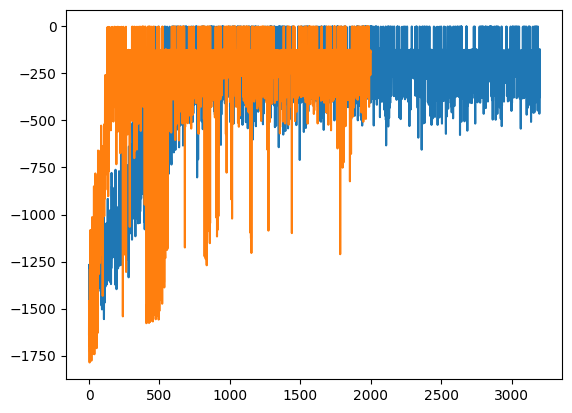

In [26]:
plt.plot(vanila_total_rewards)
plt.plot(tdr_total_rewards)
plt.show()